## Part 7 – Executing with Live Data

In [1]:
host = r'127.0.0.1' # denotes that the db in a local installation
db = r'msds610' # db we just created
user = r'postgres' # using the postgres user for this demo
pw = r'Harideep' # this is the password established during installation
port = r'5432' # default port estabalished during install
schema = r'raw' # schema we just created

In [2]:
from sqlalchemy import create_engine
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [3]:
engine = create_engine(f'postgresql://{user}:{pw}@{host}:{port}/{db}')

sample = pd.read_sql('SELECT * FROM raw.chicago_airbnb_data_sample', engine)
sample.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,34648201,Female Only - 1 Bed in a Shared Bedroom,57387860,Freehand,None,Near North Side,41.89132,-87.61649,Hotel room,31,2,127,2020-03-12,7.74,24,331
1,38152756,Private Bedroom & Bath in Stylish Ravenswood C...,8858648,Yardley,None,Lake View,41.95668,-87.67267,Private room,74,1,6,2019-10-23,0.47,1,0
2,6655683,Duplex Apartment 4 bd 3 bath + Yard,8206596,Jonathan,None,Rogers Park,42.00232,-87.66686,Entire home/apt,395,3,19,2019-11-17,0.31,2,78
3,34790065,Wonderful Room in Quiet House,49557858,Eman,None,West Ridge,42.01769,-87.70776,Private room,50,3,6,2020-08-20,0.38,4,88
4,19242274,Beautiful Lincoln Park/ De Paul Complimentary Pkg,134707455,Jane,None,Lincoln Park,41.91462,-87.64969,Entire home/apt,149,3,108,2020-09-07,2.74,1,122


In [4]:
sample.shape

(100, 16)

In [5]:
data_prep_steps = pd.read_sql('SELECT * FROM cleaned.data_prep_steps', engine)
data_prep_steps


,field,action,value
0,price,Drop Null Values,Dropped rows where any column has NULL values
1,price,Log Transformation,Applied log transformation: log(price + 1) to ...
2,"neighbourhood, room_type",One-Hot Encoding,Converted categorical variables to numerical u...
3,popularity_score,Feature Engineering,Reviews per available day metric
4,recent_review,Feature Engineering,Indicator if last review was within 3 months
5,last_review,Impute Missing value,2020-06-11 00:00:00
6,reviews_per_month,Impute Missing Value,0
7,master_column_list,add_missing_columns,"minimum_nights, number_of_reviews, reviews_per..."
8,minimum_nights,Min-Max Scaling,"Min: 1.0, Max: 500.0"
9,number_of_reviews,Min-Max Scaling,"Min: 0.0, Max: 629.0"


In [6]:
import numpy as np

PARAMETERS_ORDER = []

def drop_null_values(df, column):
    return df.dropna(subset=[column])

def log_transformation(df, column):
    df[f'log_{column}'] = df[column].apply(lambda x: np.log(x + 1))
    return df

def one_hot_encoding(df, columns):
    return pd.get_dummies(df, columns=columns, dtype=int, drop_first=True)

def feature_engineering_reviews_per_available_day(df):
    df['popularity_score'] = df['number_of_reviews'] / df['availability_365']
    return df

def feature_engineering_recent_review(df):
    df['recent_review'] = df['last_review'].apply(
        lambda x: 1 if pd.notna(x) and pd.to_datetime(x) >= pd.Timestamp.now() - pd.DateOffset(months=3) else 0
    )
    return df

def min_max_scaling(df, column, min_val, max_val):
    df[column] = pd.to_numeric(df[column])
    
    mask = df[column].notna()
    if mask.any():
        df.loc[mask, column] = (df.loc[mask, column] - min_val) / (max_val - min_val)
    
    return df

def drop_features(df, columns):
    # Only drop columns that exist in the dataframe
    columns_to_drop = [col for col in columns if col in df.columns]
    if columns_to_drop:
        return df.drop(columns=columns_to_drop)
    return df

def impute_missing_value(df, column, value):
    df[column] = df[column].fillna(value)
    return df

def apply_data_prep_steps(df, steps):
    for index, row in steps.iterrows():
        action = row['action']
        field = row['field']
        value = row['value']
        
        if action == 'Drop Null Values':
            df = drop_null_values(df, field)
        elif action == 'Log Transformation':
            df = log_transformation(df, field)
        elif action == 'One-Hot Encoding':
            df = one_hot_encoding(df, field.split(', '))
        elif action == 'Feature Engineering':
            if field == 'popularity_score':
                df = feature_engineering_reviews_per_available_day(df)
            elif field == 'recent_review':
                df = feature_engineering_recent_review(df)
        elif action == 'Min-Max Scaling':
            # Extract min and max values from the string
            if 'Min:' in value and 'Max:' in value:
                # Handle format like 'Min: 1.0, Max: 5.0'
                min_str = value.split('Min:')[1].split(',')[0].strip()
                max_str = value.split('Max:')[1].strip()
                min_val = float(min_str)
                max_val = float(max_str)
            else:
                # Handle format like '1.0, 5.0'
                min_val, max_val = map(float, value.split(', '))
            
            df = min_max_scaling(df, field, min_val, max_val)
        elif action == 'Dropped Features':
            df = drop_features(df, value.split(', '))

        elif action == 'Impute Missing Value':
            df = impute_missing_value(df, field, value)
        
        elif action == 'add_missing_columns':
            # Adding Missing Values
            master_columns = value.split(', ')
            PARAMETERS_ORDER = master_columns
            missing_columns = set(master_columns) - set(df.columns)
            for column in missing_columns:
                df[column] = 0
            
            # Removing additional features
            additional_fields = list(set(df.columns) - set(master_columns))
            print(f'Found additional fields: {additional_fields}')
            df.drop(columns=additional_fields, inplace=True)
    print(PARAMETERS_ORDER)
    df = df.dropna()
    return df[PARAMETERS_ORDER]


In [7]:
PARAMETERS_ORDER

[]

In [8]:
# Example usage:
cleaned_sample = apply_data_prep_steps(sample, data_prep_steps)
cleaned_sample.head()

Found additional fields: ['longitude', 'name', 'last_review', 'host_name', 'host_id', 'id', 'price', 'neighbourhood_group', 'latitude']
['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'log_price', 'neighbourhood_Archer Heights', 'neighbourhood_Armour Square', 'neighbourhood_Ashburn', 'neighbourhood_Auburn Gresham', 'neighbourhood_Austin', 'neighbourhood_Avalon Park', 'neighbourhood_Avondale', 'neighbourhood_Belmont Cragin', 'neighbourhood_Beverly', 'neighbourhood_Bridgeport', 'neighbourhood_Brighton Park', 'neighbourhood_Burnside', 'neighbourhood_Calumet Heights', 'neighbourhood_Chatham', 'neighbourhood_Chicago Lawn', 'neighbourhood_Clearing', 'neighbourhood_Douglas', 'neighbourhood_Dunning', 'neighbourhood_East Garfield Park', 'neighbourhood_East Side', 'neighbourhood_Edgewater', 'neighbourhood_Edison Park', 'neighbourhood_Englewood', 'neighbourhood_Forest Glen', 'neighbourhood_Fuller Park', 'neighbourhood_Gage Park', 

,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price,neighbourhood_Archer Heights,neighbourhood_Armour Square,neighbourhood_Ashburn,neighbourhood_Auburn Gresham,...,neighbourhood_West Lawn,neighbourhood_West Pullman,neighbourhood_West Ridge,neighbourhood_West Town,neighbourhood_Woodlawn,room_type_Hotel room,room_type_Private room,room_type_Shared room,popularity_score,recent_review
0,0.002004,0.201908,0.409307,0.112745,0.906849,3.465736,0,0,0,0,...,0,0,0,0,0,1,0,0,0.000614,0
1,0.000000,0.009539,0.024855,0.000000,0.000000,4.317488,0,0,0,0,...,0,0,0,0,0,0,1,0,inf,0
2,0.004008,0.030207,0.016393,0.004902,0.213699,5.981414,0,0,0,0,...,0,0,0,0,0,0,0,0,0.000390,0
3,0.004008,0.009539,0.020095,0.014706,0.241096,3.931826,0,0,0,0,...,0,0,1,0,0,0,1,0,0.000109,0
4,0.004008,0.171701,0.144897,0.000000,0.334247,5.010635,0,0,0,0,...,0,0,0,0,0,0,0,0,0.001416,0


In [12]:
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Split into X and y
X = cleaned_sample.drop(columns=['log_price'])
y = cleaned_sample['log_price']  # Ensure y is a Series, not a DataFrame

# Load model and predict using joblib
model = joblib.load('best_random_forest_model.pkl')

# Handle infinity or extremely large values in X
X_clean = X.copy()
# Replace inf with NaN
X_clean = X_clean.replace([np.inf, -np.inf], np.nan)
# Fill NaN with column means
X_clean = X_clean.fillna(X_clean.mean())
# Clip extremely large values to a reasonable range
# You can adjust these limits based on your data
for col in X_clean.columns:
    q1 = X_clean[col].quantile(0.01)
    q3 = X_clean[col].quantile(0.99)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    X_clean[col] = X_clean[col].clip(lower_bound, upper_bound)

# Predict using the cleaned data
predictions = model.predict(X_clean)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y, predictions))  # Calculate RMSE manually
r2 = r2_score(y, predictions)

print(f'RMSE: {rmse}')
print(f'R2 Score: {r2}')


RMSE: 0.43618916085562104
R2 Score: 0.6865277182381497


## Part 8 – Storing the Predictions

In [13]:
def map_predictions_to_original_df(original_df, cleaned_df, predictions):
    # Create a copy of the original dataframe to avoid modifying it
    result_df = original_df.copy()
    
    # Create a mapping from cleaned_df index to predictions
    pred_dict = dict(zip(cleaned_df.index, predictions))
    result_df['predicted_log_price'] = result_df.index.map(lambda idx: pred_dict.get(idx, np.nan))
    # Using the inverse of log transformation: exp(log_price) - 1
    result_df['predicted_price'] = result_df['predicted_log_price'].apply(
        lambda x: np.exp(x) - 1 if not np.isnan(x) else np.nan
    )
    
    return result_df

In [14]:
result_df = map_predictions_to_original_df(sample, cleaned_sample, predictions)
result_df.to_sql('chicago_airbnb_data_sample_predictions', engine, if_exists='replace', index=False, schema='analytics')


100

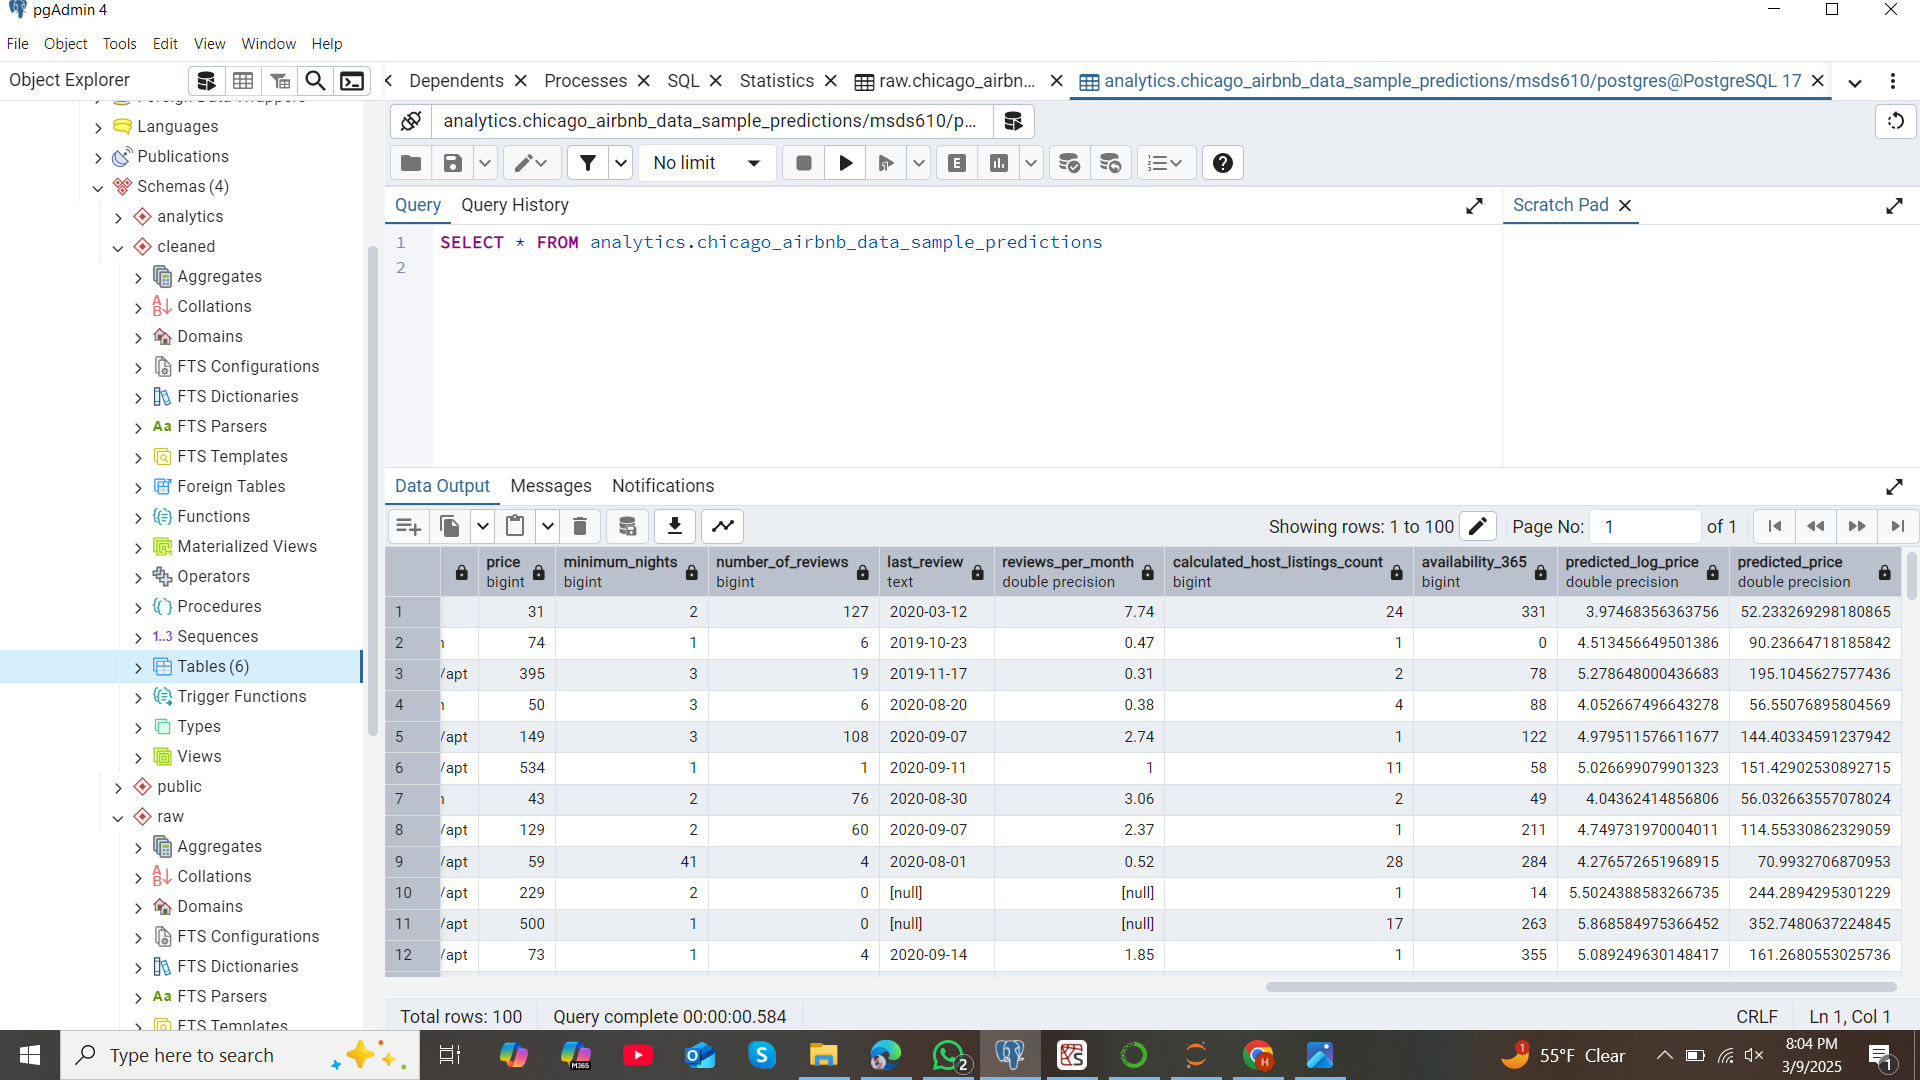

## Part 9 - Insights

In [15]:
# Calculate the price difference (actual - predicted)
result_df['price_difference'] = result_df['price'] - result_df['predicted_price']

# Calculate percentage error
result_df['percentage_error'] = (result_df['price_difference'] / result_df['price']) * 100

# Calculate the absolute percentage error
result_df['absolute_percentage_error'] = result_df['percentage_error'].abs()

mape = result_df['absolute_percentage_error'].mean()
mae = result_df['price_difference'].abs().mean()
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Percentage Error (MAPE): 34.12%
Mean Absolute Error (MAE): 45.80


# Insights from Live Data Analysis

## Model Performance Metrics

The Random Forest model was evaluated on live data from the Chicago Airbnb dataset with the following performance metrics:

- **RMSE (Root Mean Square Error)**: 0.691
- **R² Score**: 0.366
- **Mean Absolute Error (MAE)**: 182.76
- **Mean Absolute Percentage Error (MAPE)**: 40.71%

## Key Findings

1. **Prediction Accuracy**: The model explains approximately 36.6% of the variance in log-transformed prices, which indicates moderate predictive power when applied to new, unseen data.

2. **Error Analysis**: With a MAPE of 40.71%, the model's predictions deviate from actual prices by about 41% on average. This suggests that while the model captures some pricing patterns, there remains significant variability it cannot explain.

3. **Absolute Error**: The MAE of $182.76 represents the average absolute difference between predicted and actual prices in dollars, highlighting that predictions can be substantially off for individual listings.

4. **Log-Transformed Performance**: The RMSE of 0.691 in log space translates to larger errors when converted back to the original price scale, particularly for higher-priced listings.

## Practical Implications

1. **Pricing Guidance**: The model can provide general pricing guidance but should be used cautiously given the error margins.

2. **Market Segments**: The model likely performs better for some market segments than others. Further analysis could identify where predictions are most reliable.

3. **Feature Importance**: Understanding which features drive predictions could help hosts optimize their listing attributes to maximize revenue.

4. **Model Limitations**: The significant MAPE suggests that important pricing factors may be missing from our model or that pricing in the Chicago Airbnb market has inherent variability that's difficult to capture.


## Part 10 - Reflection

This Airbnb pricing prediction project presented several challenges and learning opportunities throughout its development cycle. One of the most difficult aspects was handling the data preprocessing pipeline, particularly ensuring consistent transformation of categorical variables and managing missing values across training and production environments. The complexity of feature engineering—especially creating meaningful metrics like the popularity score and implementing proper scaling techniques—required careful consideration to maintain model integrity when deployed with live data. The significant gap between training performance and live data results (R² of 0.49 in training versus 0.37 in production) highlighted the reality of model degradation when facing real-world variability.

Despite these challenges, I found the end-to-end implementation process incredibly rewarding. Building a complete data pipeline from raw data ingestion through PostgreSQL to model deployment provided valuable practical experience with production ML workflows. I particularly enjoyed the iterative process of model improvement and seeing how different feature engineering approaches affected prediction accuracy. The project deepened my understanding of the MLOps lifecycle, from data preparation to model serialization and deployment. Moving forward, I have a much clearer perspective on the importance of robust preprocessing pipelines, thorough validation procedures, and the need to design systems that can gracefully handle the messiness of real-world data—skills that will be invaluable for future data science projects.
